1. Hotelling's $T^{2}$ Test for a Mean Vector

In [8]:
X <- matrix(c(2, 8, 6, 8,
              12, 9, 9, 10), ncol = 2)
mu_0 <- c(7, 11)
n <- nrow(X)
p <- ncol(X)

x_bar <- colMeans(X)
S <- cov(X)
S_inv <- solve(S)
T2 <- as.numeric(n * t(x_bar - mu_0) %*% S_inv %*% (x_bar - mu_0))
cat("(a) T^2 Statistic:", T2, "\n")

cat("(b) Distribution: [ (", n-1, "*", p, ") / (", n, "-", p, ") ] * F(p=", p, ", n-p=", n-p, ")\n")

alpha <- 0.05
F_stat <- T2 * (n - p) / (p * (n - 1))
p_val <- 1 - pf(F_stat, df1 = p, df2 = n - p)
F_crit <- qf(1 - alpha, df1 = p, df2 = n - p)
T2_crit <- F_crit * (p * (n - 1)) / (n - p)

cat("(c) P-value:", p_val, "\n")
cat("T^2 Critical Value:", T2_crit, "\n")

if(T2 > T2_crit) {
  cat("Conclusion: Reject H0. The mean vector is significantly different from [7, 11].\n")
} else {
  cat("Conclusion: Fail to reject H0. There is not enough evidence to conclude the population mean vector is different from [7, 11].\n")
}

(a) T^2 Statistic: 13.63636 
(b) Distribution: [ ( 3 * 2 ) / ( 4 - 2 ) ] * F(p= 2 , n-p= 2 )
(c) P-value: 0.1803279 
T^2 Critical Value: 57 
Conclusion: Fail to reject H0. There is not enough evidence to conclude the population mean vector is different from [7, 11].


2. Simultaneous Confidence Intervals and Regions for Grizzly Bear Body Measurements

(a) Large-sample 95% Simultaneous CIs:
                Lower     Upper
Weight       69.55347 121.48653
Body_Length 152.17278 176.58722
Neck_Girth   49.60667  61.77333
Girth        83.48823 103.29177
Head_Length  16.54687  19.41313
Head_Width   29.03513  33.22487

(b) Constructing 95% Simultaneous Confidence Ellipse (see plot output).

(c) 95% Bonferroni CIs (m=6):
                Lower     Upper
Weight       75.55331 115.48669
Body_Length 154.99339 173.76661
Neck_Girth   51.01229  60.36771
Girth        85.77614 101.00386
Head_Length  16.87801  19.08199
Head_Width   29.51917  32.74083

(d) Overlaying Bonferroni rectangle on the plot.

(e) Bonferroni CI for Head Width - Head Length (m=7): [ 12.48757 , 13.81243 ]


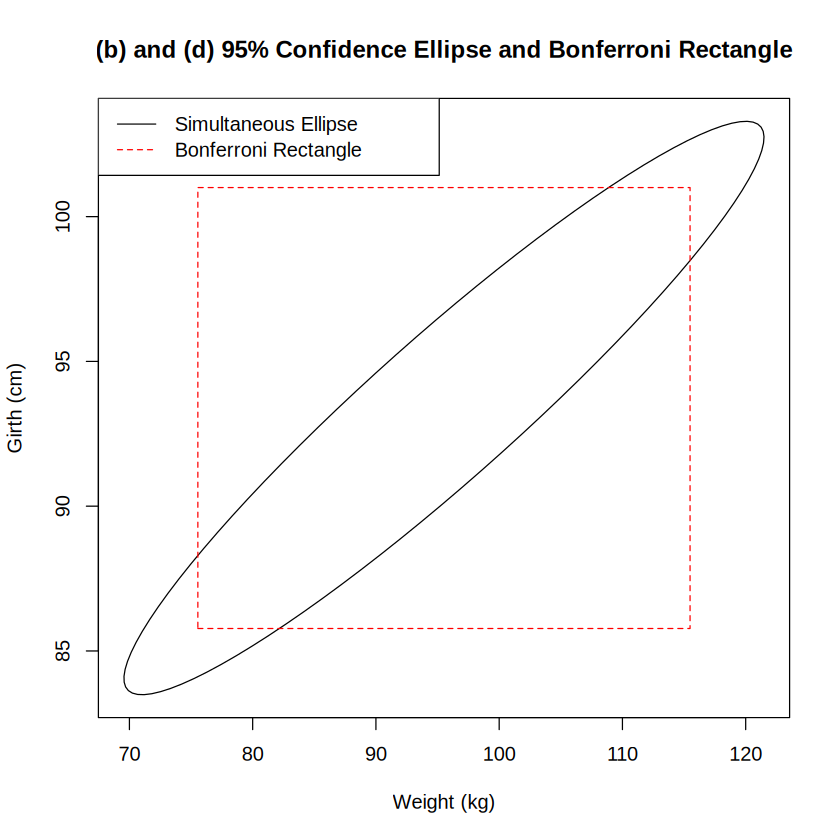

In [9]:
n <- 61
p <- 6
alpha <- 0.05
x_bar <- c(95.52, 164.38, 55.69, 93.39, 17.98, 31.13)
names(x_bar) <- c("Weight", "Body_Length", "Neck_Girth", "Girth", "Head_Length", "Head_Width")

S <- matrix(c(
  3266.46, 1343.97, 731.54, 1175.50, 162.68, 238.37,
  1343.97, 721.91, 324.25, 537.35, 80.17, 117.73,
  731.54, 324.25, 179.28, 281.17, 39.15, 56.80,
  1175.50, 537.35, 281.17, 474.98, 63.73, 94.85,
  162.68, 80.17, 39.15, 63.73, 9.95, 13.88,
  238.37, 117.73, 56.80, 94.85, 13.88, 21.26
), nrow = 6, byrow = TRUE)

chi2_crit <- qchisq(1 - alpha, df = p)
margin_simult <- sqrt(chi2_crit * diag(S) / n)
CI_simult <- cbind(Lower = x_bar - margin_simult, Upper = x_bar + margin_simult)

cat("(a) Large-sample 95% Simultaneous CIs:\n")
print(CI_simult)

plot_ellipse <- function(center, shape, radius, xlab, ylab, main) {
  theta <- seq(0, 2 * pi, length.out = 100)
  circle <- cbind(cos(theta), sin(theta))
  eig <- eigen(shape)
  half_shape <- eig$vectors %*% diag(sqrt(eig$values)) %*% t(eig$vectors)
  ell <- t(center + radius * t(circle %*% half_shape))
  plot(ell, type = "l", xlab = xlab, ylab = ylab, main = main)
}

cat("\n(b) Constructing 95% Simultaneous Confidence Ellipse (see plot output).\n")
ellipse_indices <- c(1, 4)
plot_ellipse(
  center = x_bar[ellipse_indices],
  shape = S[ellipse_indices, ellipse_indices],
  radius = sqrt(chi2_crit / n),
  xlab = "Weight (kg)", ylab = "Girth (cm)",
  main = "(b) and (d) 95% Confidence Ellipse and Bonferroni Rectangle"
)

m <- p
t_crit_bonf <- qt(1 - alpha / (2 * m), df = n - 1)
margin_bonf <- t_crit_bonf * sqrt(diag(S) / n)
CI_bonf <- cbind(Lower = x_bar - margin_bonf, Upper = x_bar + margin_bonf)

cat("\n(c) 95% Bonferroni CIs (m=6):\n")
print(CI_bonf)

cat("\n(d) Overlaying Bonferroni rectangle on the plot.\n")
rect(
  xleft = CI_bonf[1, "Lower"], ybottom = CI_bonf[4, "Lower"],
  xright = CI_bonf[1, "Upper"], ytop = CI_bonf[4, "Upper"],
  border = "red", lty = 2
)
legend("topleft", legend = c("Simultaneous Ellipse", "Bonferroni Rectangle"),
       col = c("black", "red"), lty = c(1, 2))

m_new <- 7
t_crit_bonf_new <- qt(1 - alpha / (2 * m_new), df = n - 1)
a <- c(0, 0, 0, 0, -1, 1)
diff_mean <- sum(a * x_bar)
diff_var <- as.numeric(t(a) %*% S %*% a) / n
margin_diff <- t_crit_bonf_new * sqrt(diff_var)

cat("\n(e) Bonferroni CI for Head Width - Head Length (m=7): [", diff_mean - margin_diff, ",", diff_mean + margin_diff, "]\n")

3. Mineral Analysis of Ancient Peruvian Hairs

(a) Constructing 90% Joint Confidence Ellipse (see plot output).

(b) Simultaneous 90% CIs:
        Lower    Upper
Cr -0.2147893 64.26590
St -2.5640884 51.86409
[0.30, 10] is a plausible value, it falls outside the joint confidence region.

(c) Generating normality plots (see plot output).


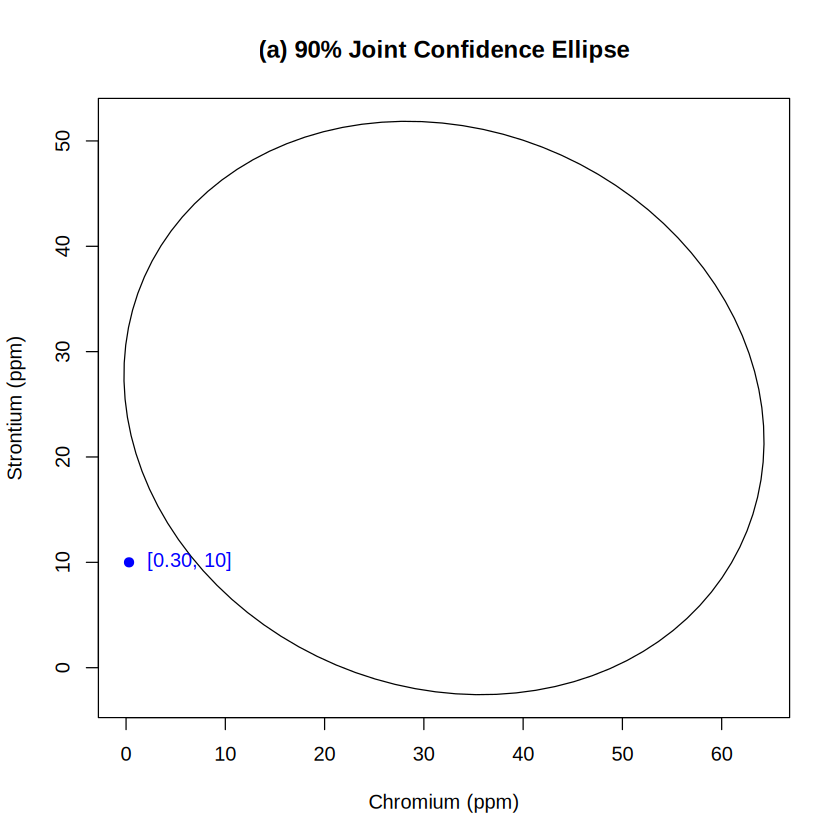


(d) Most extreme outlier detected at index 6 and removed.
Re-evaluating plausibility of [0.30, 10] with clean data...
    It is NO LONGER plausible (falls outside the updated region).


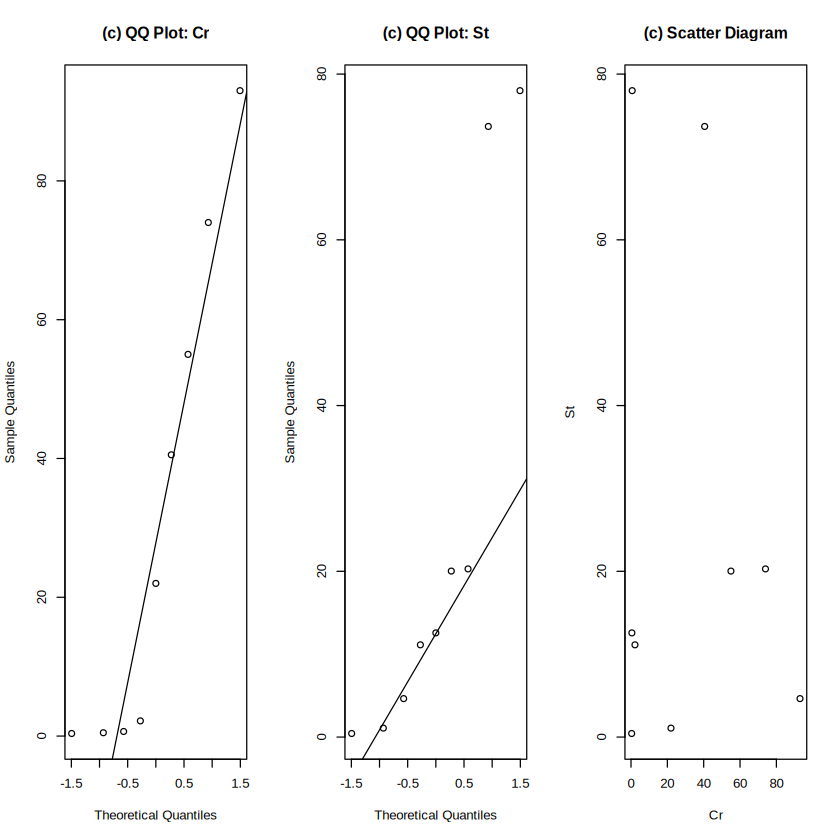

In [14]:
x1 <- c(0.48, 40.53, 2.19, 55, 74, 0.66, 93, 0.37, 22)
x2 <- c(12.57, 73.68, 11.13, 20.03, 20.29, 78, 4.64, 0.43, 1.08)
hair_data <- data.frame(Cr = x1, St = x2)
n_hair <- nrow(hair_data)
p_hair <- ncol(hair_data)
alpha_hair <- 0.10

x_bar_hair <- colMeans(hair_data)
S_hair <- cov(hair_data)
F_crit_hair <- qf(1 - alpha_hair, p_hair, n_hair - p_hair)
radius_hair <- sqrt(p_hair * (n_hair - 1) / (n_hair * (n_hair - p_hair)) * F_crit_hair)

plot_ellipse <- function(center, shape, radius, xlab, ylab, main) {
  theta <- seq(0, 2 * pi, length.out = 100)
  circle <- cbind(cos(theta), sin(theta))
  eig <- eigen(shape)
  half_shape <- eig$vectors %*% diag(sqrt(eig$values)) %*% t(eig$vectors)
  ell <- t(center + radius * t(circle %*% half_shape))
  plot(ell, type = "l", xlab = xlab, ylab = ylab, main = main)
}

cat("(a) Constructing 90% Joint Confidence Ellipse (see plot output).\n")
plot_ellipse(
  center = x_bar_hair,
  shape = S_hair,
  radius = radius_hair,
  xlab = "Chromium (ppm)", ylab = "Strontium (ppm)",
  main = "(a) 90% Joint Confidence Ellipse"
)
points(0.30, 10, col="blue", pch=19)
text(0.30, 10, " [0.30, 10]", col="blue", pos=4)

margin_hair <- radius_hair * sqrt(diag(S_hair))
CI_hair_simult <- cbind(Lower = x_bar_hair - margin_hair, Upper = x_bar_hair + margin_hair)

cat("\n(b) Simultaneous 90% CIs:\n")
print(CI_hair_simult)

T2_test_vector <- as.numeric(n_hair * t(c(0.30, 10) - x_bar_hair) %*% solve(S_hair) %*% (c(0.30, 10) - x_bar_hair))
T2_crit_hair <- p_hair * (n_hair - 1) / (n_hair - p_hair) * F_crit_hair
if(T2_test_vector <= T2_crit_hair) {
  cat("[0.30, 10] is a plausible value, it is inside the joint confidence region.\n")
} else {
  cat("[0.30, 10] is a plausible value, it falls outside the joint confidence region.\n")
}

cat("\n(c) Generating normality plots (see plot output).\n")
par(mfrow=c(1,3))
qqnorm(hair_data$Cr, main="(c) QQ Plot: Cr")
qqline(hair_data$Cr)
qqnorm(hair_data$St, main="(c) QQ Plot: St")
qqline(hair_data$St)
plot(hair_data$Cr, hair_data$St, main="(c) Scatter Diagram", xlab="Cr", ylab="St")
par(mfrow=c(1,1))

D2 <- mahalanobis(hair_data, x_bar_hair, S_hair)
outlier_idx <- which.max(D2)
hair_data_clean <- hair_data[-outlier_idx, ]
cat("\n(d) Most extreme outlier detected at index", outlier_idx, "and removed.\n")

n_clean <- nrow(hair_data_clean)
x_bar_clean <- colMeans(hair_data_clean)
S_clean <- cov(hair_data_clean)
F_crit_clean <- qf(1 - alpha_hair, p_hair, n_clean - p_hair)

T2_test_clean <- as.numeric(n_clean * t(c(0.30, 10) - x_bar_clean) %*% solve(S_clean) %*% (c(0.30, 10) - x_bar_clean))
T2_crit_clean <- p_hair * (n_clean - 1) / (n_clean - p_hair) * F_crit_clean

cat("Re-evaluating plausibility of [0.30, 10] with clean data...\n")
if(T2_test_clean <= T2_crit_clean) {
  cat("    It is STILL plausible (inside the updated region).\n")
} else {
  cat("    It is NO LONGER plausible (falls outside the updated region).\n")
}

4. Lumber Strength Measurements

(a) Constructing 95% Confidence Ellipse (see plot output).

(b) Testing consistency of [2000, 10000]:
    The data ARE NOT consistent with these values (falls outside ellipse).

(c) Generating Chi-Square QQ Plot to assess bivariate normality (see plot output).


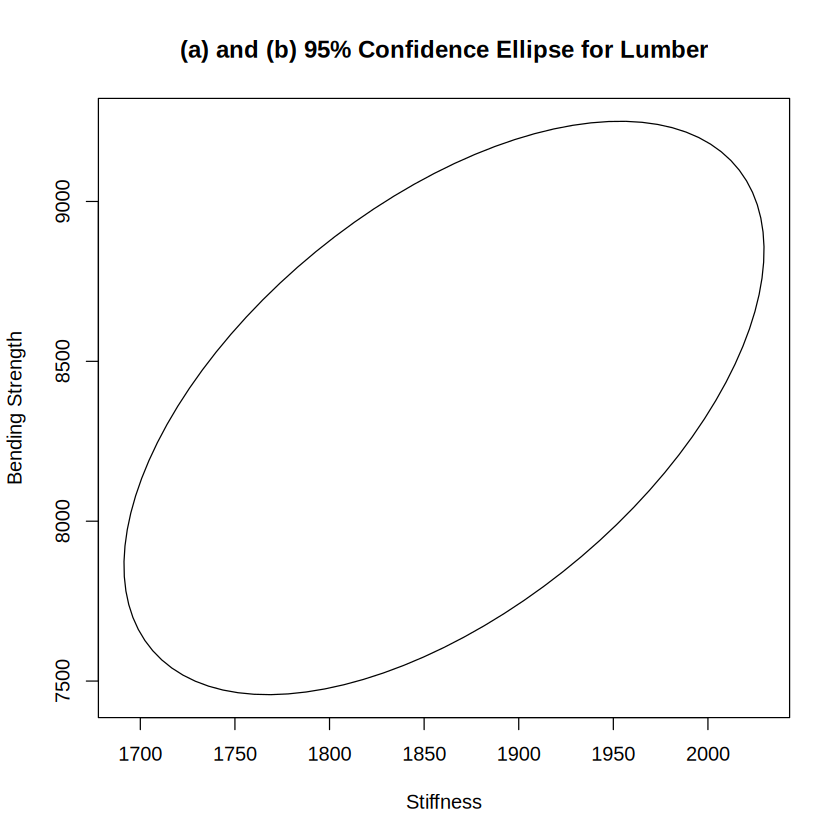

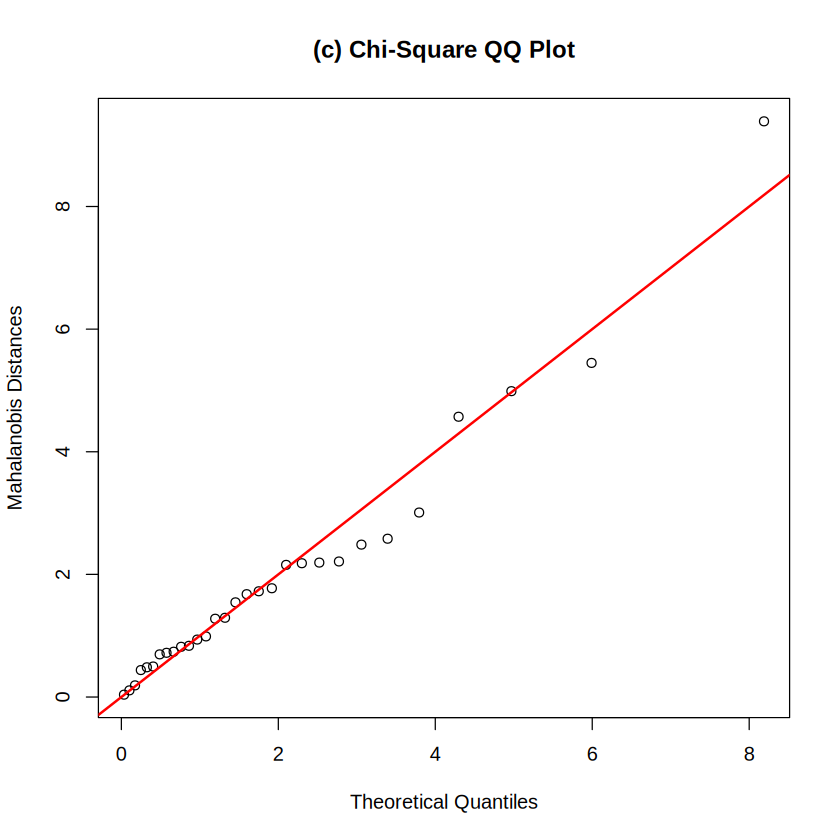

In [11]:
stiffness <- c(1232, 1115, 2205, 1897, 1932, 1612, 1598, 1804, 1752, 2067, 2365, 1646, 1579, 1880, 1773,
               1712, 1932, 1820, 1900, 2426, 1558, 1470, 1858, 1587, 2208, 1487, 2206, 2332, 2540, 2322)
bending <- c(4175, 6652, 7612, 10914, 10850, 7627, 6954, 8365, 9469, 6410, 10327, 7320, 8196, 9709, 10370,
             7749, 6818, 9307, 6457, 10102, 7414, 7556, 7833, 8309, 9559, 6255, 10723, 5430, 12090, 10072)
lumber <- data.frame(Stiffness = stiffness, Bending = bending)
n_lumb <- nrow(lumber)
p_lumb <- 2
alpha_lumb <- 0.05

x_bar_lumb <- colMeans(lumber)
S_lumb <- cov(lumber)
F_crit_lumb <- qf(1 - alpha_lumb, p_lumb, n_lumb - p_lumb)
rad_lumb <- sqrt(p_lumb * (n_lumb - 1) / (n_lumb * (n_lumb - p_lumb)) * F_crit_lumb)

plot_ellipse <- function(center, shape, radius, xlab, ylab, main) {
  theta <- seq(0, 2 * pi, length.out = 100)
  circle <- cbind(cos(theta), sin(theta))
  eig <- eigen(shape)
  half_shape <- eig$vectors %*% diag(sqrt(eig$values)) %*% t(eig$vectors)
  ell <- t(center + radius * t(circle %*% half_shape))
  plot(ell, type = "l", xlab = xlab, ylab = ylab, main = main)
}

cat("(a) Constructing 95% Confidence Ellipse (see plot output).\n")
plot_ellipse(
  center = x_bar_lumb,
  shape = S_lumb,
  radius = rad_lumb,
  xlab = "Stiffness", ylab = "Bending Strength",
  main = "(a) and (b) 95% Confidence Ellipse for Lumber"
)

mu_0_lumb <- c(2000, 10000)
points(mu_0_lumb[1], mu_0_lumb[2], col = "red", pch = 19)
text(mu_0_lumb[1], mu_0_lumb[2], "(b) [2000, 10000]", col = "red", pos = 4)

T2_lumb_test <- as.numeric(n_lumb * t(mu_0_lumb - x_bar_lumb) %*% solve(S_lumb) %*% (mu_0_lumb - x_bar_lumb))
T2_crit_lumb <- p_lumb * (n_lumb - 1) / (n_lumb - p_lumb) * F_crit_lumb
cat("\n(b) Testing consistency of [2000, 10000]:\n")
if(T2_lumb_test <= T2_crit_lumb) {
  cat("    The data ARE consistent with these values (falls inside ellipse).\n")
} else {
  cat("    The data ARE NOT consistent with these values (falls outside ellipse).\n")
}

D2_lumb <- mahalanobis(lumber, x_bar_lumb, S_lumb)
cat("\n(c) Generating Chi-Square QQ Plot to assess bivariate normality (see plot output).\n")
qqplot(qchisq(ppoints(n_lumb), df = p_lumb), D2_lumb,
       main = "(c) Chi-Square QQ Plot",
       xlab = "Theoretical Quantiles", ylab = "Mahalanobis Distances")
abline(0, 1, col = 'red', lwd=2)